In [1]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%load_ext autoreload
%autoreload 2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)


In [3]:
adata.obs

,Area,CellID,Centroid,Polygons,Sample,X,Y,batch,ID,m-states80,tumour_vs_astrocyte,m-states
7-0-0-0,415.221863,7,POINT (2158.941554680706 4833.13708372292),"POLYGON ((2145.279215047813 4818.870960252711,...",SL001A,2156.249268,4833.224609,0,1,0,NA,GBL-like 1
8-0-0-0,469.549744,8,POINT (1985.781334717601 5396.793561399669),POLYGON ((1985.9166577902154 5377.953700362764...,SL001A,1986.922729,5395.872070,0,2,0,NA,GBL-like 1
11-0-0-0,259.442017,11,POINT (6896.852311068986 4889.538959933898),POLYGON ((6888.217662201816 4874.4611507128475...,SL001A,6901.555176,4894.149902,0,3,0,NA,GBL-like 1
12-0-0-0,332.676941,12,POINT (5739.986429677047 3286.681204587582),POLYGON ((5734.996442214184 3267.5403448049537...,SL001A,5740.708984,3287.107178,0,4,0,NA,GBL-like 1
13-0-0-0,241.888336,13,POINT (5119.742451593253 2987.7058187325624),"POLYGON ((5112.675349025511 2972.485718365772,...",SL001A,5118.480469,2988.299072,0,5,0,NA,GBL-like 1
...,...,...,...,...,...,...,...,...,...,...,...,...
9056381-21-40-39-1,210.595444,193402,POINT (8976.937328904738 7448.842597542862),"POLYGON ((8983.844864864297 7442.98859837559, ...",SL061C,8977.596680,7448.586914,1,3472139,71,NA,TAM-BDM 4
9056383-21-40-39-1,164.257339,193404,POINT (17634.06244805338 9073.924665118115),"POLYGON ((17626.996410456035 9066.64182797968,...",SL061C,17634.564453,9074.173828,1,3472141,71,NA,TAM-BDM 4
9056384-21-40-39-1,120.001312,193405,POINT (9794.430083517545 8205.123165701289),"POLYGON ((9796.67814096396 8197.659490156591, ...",SL061C,9796.544922,8203.919922,1,3472142,71,NA,TAM-BDM 4
9056386-21-40-39-1,172.908417,193407,POINT (21637.902240121395 4973.694163172527),POLYGON ((21635.755377483965 4963.807635038284...,SL061C,21638.259766,4973.062988,1,3472144,71,NA,TAM-BDM 4


In [4]:
palette = {
    'AC-like':'#2ecc71',#inchworm B4FF9F
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    
    
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F
    'AC-like 8':'#2ecc71',#inchworm B4FF9F

    'preOPC-like 1':'#7befb2',#'#c2f970'

    'WR Periphery1': '#EDE8F3',
    'WR Periphery2': '#E2D8EA',
    'WR Periphery3': '#D6BEDD',
    'WR Endo.Ass.': '#CFA8D1',
    'WR nIPC': '#CA90C5',
    'WR OPC': '#D873B6',
    'WR HYPR1': '#C50F53',
    'WR HYPR2': '#840034',
        
    
    'nIPC-like 1':'#FFF192',
    'nIPC-like 2':'#FFF192',
    'nIPC-like 3':'#FFF192',

    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise
    'OPC-like 3':'#89c4f4', #bright turquoise
    'OPC-like':'#89c4f4',
    
    #'Endothelial':'#d5b8ff', #mauve
    'Endothelial 1':'#8c14fc',#'#d5b8ff', #mauve
    'Endothelial':'#8c14fc',#'#d5b8ff', #mauve
    'Mural cell': '#8c14fc',  #electric indigo
    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural': '#8c14fc',  #electric indigo
    
    'Fibroblast': '#fbe7ef',
    'FB-like 2': '#FF6EC7', #fff9de
    'FB-like 3': '#FF6EC7', #fff9de
     #'FB-like 1': '#FF6EC7', #fff9de

    'Mono 1': '#c8f7c5',#'#e6d9cb',#'#cdd1e4',#'#f4ede4',
    'Mono 2': '#FBFCFA',
    
    'TAM-MDM 1':'#e88474',#'#F5C9B0',
    'TAM-MDM 2':'#A94A54',
    
    'TAM-MDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-MDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-BDM 1':'#e88474',#'#F5C9B0',
    'TAM-BDM 2':'#A94A54',
    
    'TAM-BDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-BDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-MG':'#825e5c', #'#00b5cc' (blue),
    
    'DC': '#a6915c',
}

palette_classes = {
    'GBL-like':'#c2f970',#'#c2f970'
    'AC-like':'#2ecc71',#inchworm B4FF9F
    'preOPC-like':'#7befb2',#'#c2f970'

    #'MES-like': '#EDE8F3',
    'WR': '#e76d89',
    'nIPC-like':'#FFF192',
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like':'#89c4f4',

    'FB-like': '#f1e7fe',#'#FF6EC7', #fff9de

}

In [5]:
import pandas as pd
adata.obs['m-states'] = pd.Categorical(['Mural' if x.count('Mural') else x for x in adata.obs['m-states']])
adata.obs['Class'] = pd.Categorical(['unknown' if x.count('FB-like 1') else x for x in adata.obs['m-states']])
adata.obs['Class'] = pd.Categorical([x.split(' ')[0] for x in adata.obs.Class])

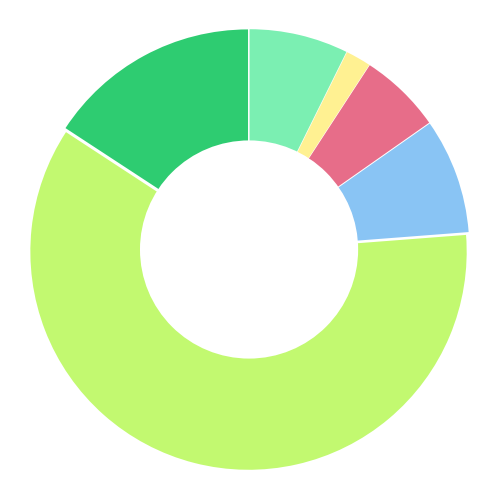

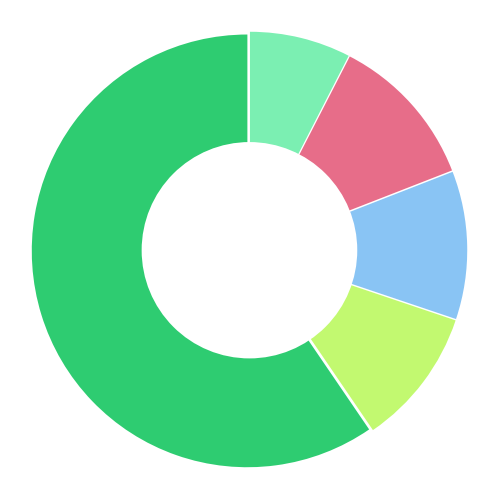

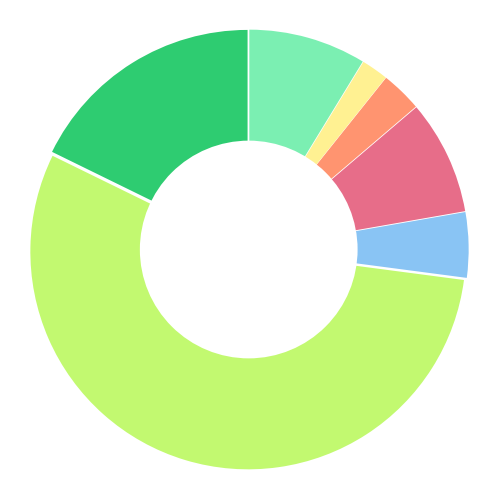

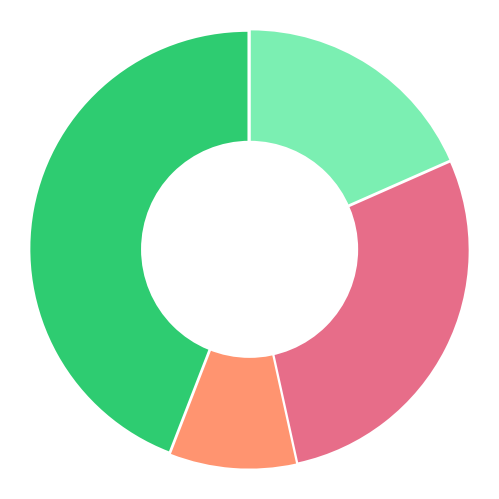

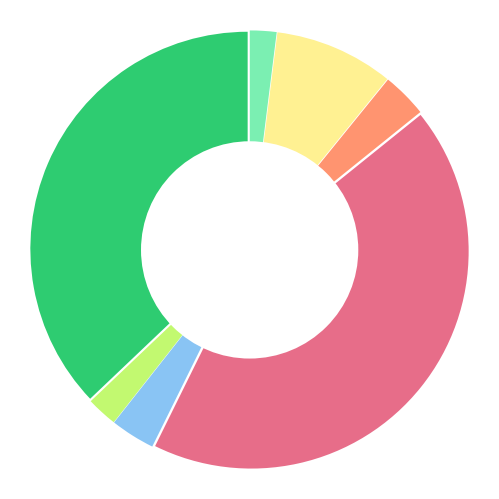

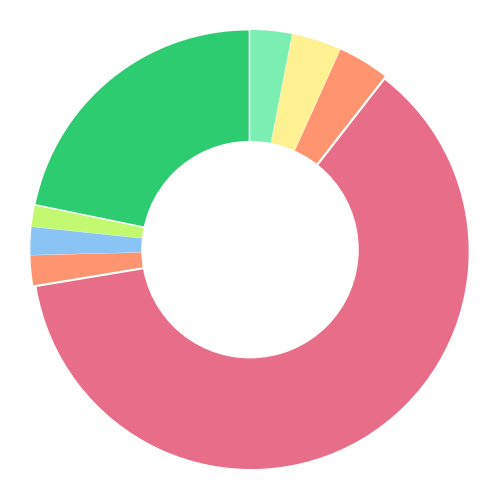

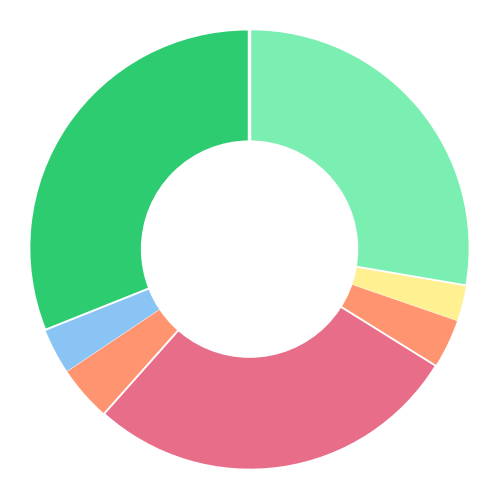

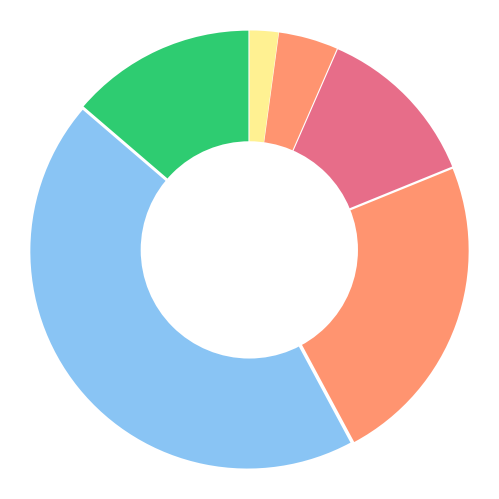

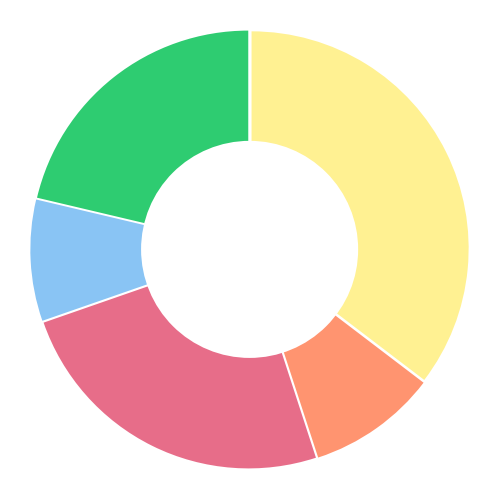

In [6]:
import matplotlib.pyplot as plt
# Pie chart
for s in ['SL001A','SL001B', 'SL003','SL006', 'SL046C','SL035B', 'SL061B', 'SL023', 'SL034']:
    sadata = adata[adata.obs.Sample == s]
    sadata = sadata[sadata.X.sum(axis=1)>20]
    
    #df_table = sadata.obs.pivot_table(values='Area', index='Class', aggfunc=np.sum)
    #df_table = df_table.loc[list(palette_classes.keys()),:]
    #p = df_table.Area/df_table.Area.sum() *100
    #df_table = df_table[p > 2.5]
    #classes = df_table.index.values
    #counts = df_table.Area.values
    
    classes, counts = np.unique(sadata.obs['Class'], return_counts=True)
    
    counts = counts[np.isin(classes,  list(palette_classes.keys()))]
    classes = classes[np.isin(classes, list(palette_classes.keys()))]
    
    p = counts/counts.sum() *100 > 1.5
    counts = counts[p]
    classes = classes[p]
    
    

    labels = [c.split('-')[0] for c in classes]
    sizes = counts
    #colors
    colors = [palette_classes[x] for x in classes]
    #explsion
    explode = [0.01 for c in classes]
    fig1, ax1 = plt.subplots(1,1,figsize=(5,5))
    kwargs={'fontsize':16},
    ax1.pie(
        sizes, 
        colors = colors, 
        #labels=labels, 
        #autopct='%1.1f%%', 
        startangle=90, 
        pctdistance=0.85,
        labeldistance=0.75,
        explode = explode,
        textprops={'fontsize': 12}
        #kwargs=**kwargs,
    )
    #draw circle
    centre_circle = plt.Circle((0,0),0.50,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax1.axis('equal')  
    plt.tight_layout()
    plt.savefig(f'figures/pie{s}.pdf',transparent=True)
    plt.show()

INFO:root:First filter, 92078 cells left
INFO:root:Zoom filter, 92078 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


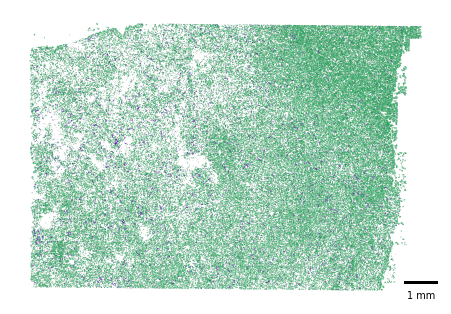

In [7]:

sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    palette=palette,
    #geometry_key='Centroid',
    cluster_key= 'Class',
    clusters = ['AC-like','Mural','Endothelial'],
    markersize=.25,
    figsize=(5,5),

    show_scalebar=True,
    show_axis=False,
    save=True,
    savepath='figures/SL061B.svg',
    
)

INFO:root:First filter, 367612 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 81670 cells left
INFO:root:Expression range: 1.0 - 12.0
INFO:root:First filter, 7181 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 1755 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


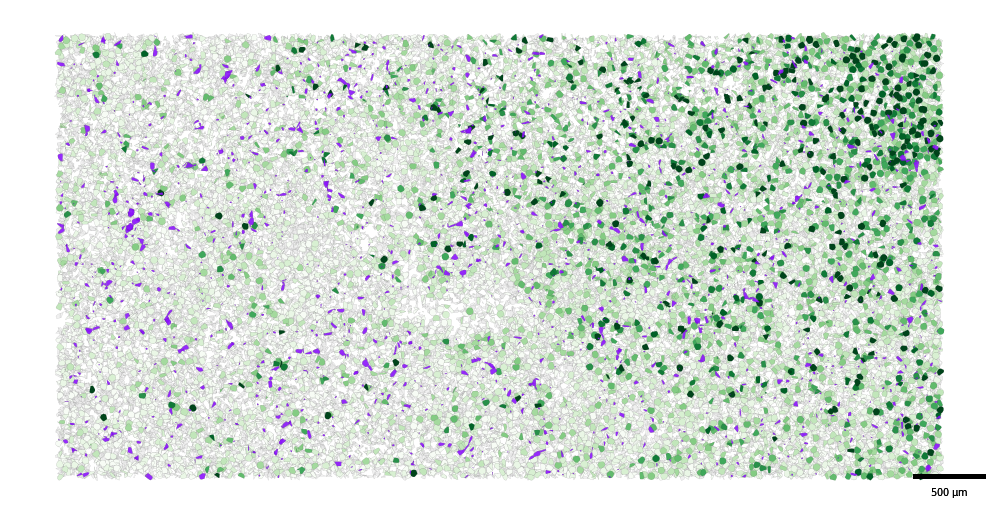

In [8]:
xlim= (2000, 8000)
ylim = (4000, 7000)

fig,ax = plt.subplots(1,1 ,figsize=(10,10))
sp.pl.plot_polygons_expression(
    adata,
    sample='SL061B',
    genes=['CRYAB'],
    cluster_key='m-states',
    cmap='Greens',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    #figsize=(5,5),
    mquant=0.995,
    ax = ax

)

sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#8c14fc',  'Mural': '#8c14fc'},
    ax=ax,
)

plt.savefig('figures/CRYAB_SL061B.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

INFO:root:First filter, 367612 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 81670 cells left
INFO:root:Expression range: 1.0 - 12.0
INFO:root:First filter, 7181 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 1755 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


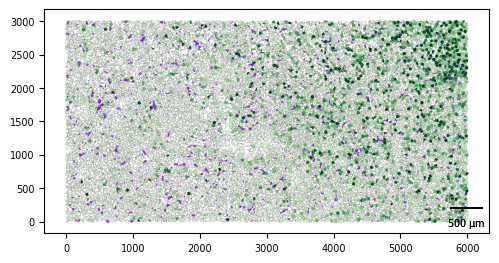

In [9]:
xlim= (2000, 8000)
ylim = (4000, 7000)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))
sp.pl.plot_polygons_expression(
    adata,
    sample='SL061B',
    genes=['CRYAB'],
    cmap='Greens',
    cluster_key='m-states',
    #clusters= ['MES-like 1', 'MES-like 2', 'MES-like 3', 'MES-like 4', 'MES-like 5', 'MES-like 6', 'MES-like 7', 'MES-like 8'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=True,
    #figsize=(5,5),
    mquant=0.995,
    ax = ax
    #save=True,
    #savepath='figures/SL035B_zoom.svg',
)

sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#8c14fc',  'Mural': '#8c14fc'},
    ax=ax,
)

INFO:root:First filter, 367612 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 1414 cells left
INFO:root:Expression range: 1.0 - 12.0
INFO:root:First filter, 7181 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 27 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


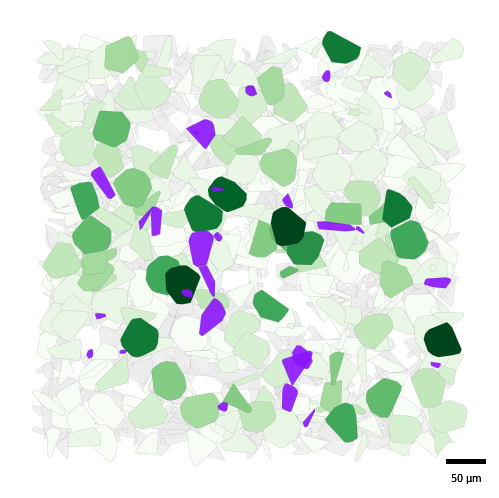

In [10]:
xlim= (5500, 6000)
ylim = (4750, 5250)


fig,ax = plt.subplots(1,1 ,figsize=(5,5))
sp.pl.plot_polygons_expression(
    adata,
    sample='SL061B',
    genes=['CRYAB'],
    cmap='Greens',
    cluster_key='m-states',
    #clusters= ['MES-like 1', 'MES-like 2', 'MES-like 3', 'MES-like 4', 'MES-like 5', 'MES-like 6', 'MES-like 7', 'MES-like 8'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    #figsize=(5,5),
    mquant=0.995,
    ax = ax
    #save=True,
    #savepath='figures/SL035B_zoom.svg',
)

sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=False,
    palette= {'Endothelial':'#8c14fc',  'Mural': '#8c14fc'},
    ax=ax,
)
plt.savefig('figures/CRYAB_SL061B_zoom.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

In [ ]:
from FISHscale.utils.dataset import Dataset
from skimage import img_as_bool
from skimage.transform import rescale
import zarr

DS = Dataset('../../data_for_visualization/JJEXP20220725_EEL_SL061B_S1_RNA_transformed_assigned.parquet',
             gene_label='decoded_genes',
             pixel_size='0.27 micrometers',
             reparse=True,
            )

'''
img = zarr.load('../../data_for_visualization/JJEXP20220725_EEL_SL061B_S1_image_segmented_labels.zarr/segmented_labels_image/')
#img = np.flip(img, axis=0)
img[img >0] = 1
img_d = rescale(img, 0.27, anti_aliasing=False)
img_d[img_d >0] = 1
img_d = img_as_bool(img_d)
#x1, y1, x2, y2 = x1*0.27, y1*0.27, x2*0.27, y2*0.27

'''

INFO:root:Please install "BoneFight" or its missing dependencies. Error message: No module named 'bone_fight'
INFO:root:Could not import Cellpose. Ignore if cell segmentation is not needed. Error: No module named 'cellpose'
 99%|█████████████████████████████████████▋| 1311/1324 [00:07<00:00, 215.35it/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████████████████████████████████| 1324/1324 [00:07<00:00, 169.73it/s]


2025-10-29 11:31:20,485 - INFO -     Loaded: JJEXP20220725_EEL_SL061B_S1_RNA_transformed_assigned


"img = zarr.load('/date/sl/fish_rawdata/JJEXP20220725_EEL_SL061B_S1/fresh_tissue/segmentation/image_segmented_labels.zarr/segmented_labels_image/')\n#img = np.flip(img, axis=0)\nimg[img >0] = 1\nimg_d = rescale(img, 0.27, anti_aliasing=False)\nimg_d[img_d >0] = 1\nimg_d = img_as_bool(img_d)\n#x1, y1, x2, y2 = x1*0.27, y1*0.27, x2*0.27, y2*0.27\n\n"

In [12]:
from matplotlib import colors as mcolors
DS.color_dict['FN1'] = mcolors.rgb2hex(palette['Mural'])
DS.color_dict['ITM2A'] = mcolors.rgb2hex('#d5b8ff')
DS.color_dict['CLDN5'] = mcolors.rgb2hex('#e33d94')

DS.color_dict['CRYAB'] = mcolors.rgb2hex(palette_classes['AC-like'])
DS.color_dict['AQP4'] = mcolors.rgb2hex('#038aff')


AttributeError: 'Legend' object has no attribute 'legendHandles'

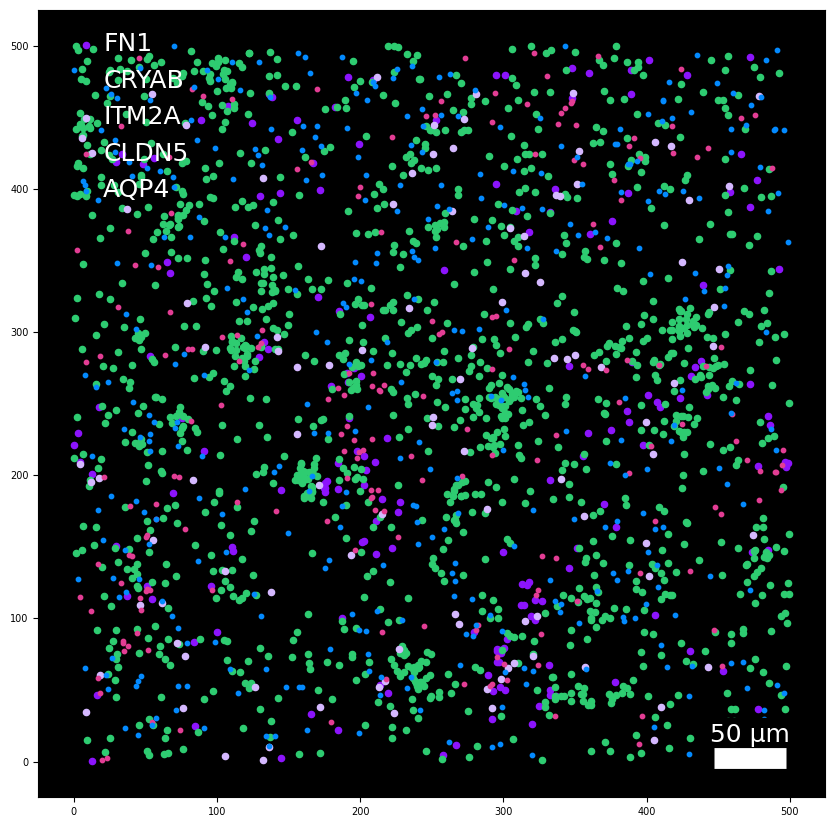

In [13]:
xlim= (2000, 8000)
ylim = (4000, 7000)

xlim= (5500, 6000)
ylim = (4750, 5250)

xlim_rev = ()
ylim_rev = ()

v =  [[xlim[0], ylim[0]],[xlim[1],ylim[1]]]

scale_factor = 1#0.27*4.5
#img_zoom = img_d[int(v[0][1]*scale_factor):int(v[1][1]*scale_factor),int(v[0][0]*scale_factor):int(v[1][0]*scale_factor)]

sizes = [20, 20, 20, 10, 10] 
genes = ['FN1','CRYAB','ITM2A','CLDN5','AQP4']

fig,ax = plt.subplots(1,1 ,figsize=(5,5))

DS.scatter_plot(
    genes,
    s=sizes,
    ax_scale_factor=400,
    show_axes=True,
    show_legend=True,
    view = v,
    #image=img_zoom,
    reset_xy=True,
    ax=ax,
    save=True,
    save_name='figures/SL061B_dots.svg'
)



# Oligodendroglioma

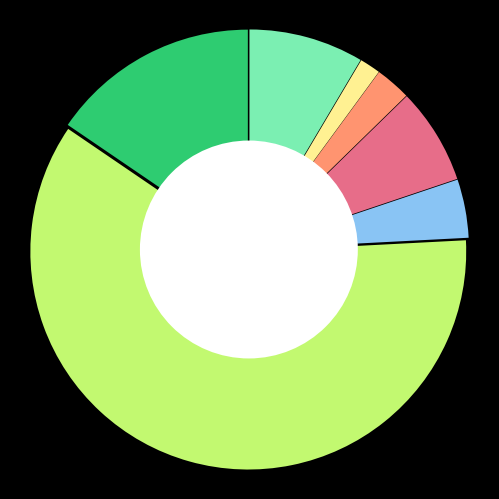

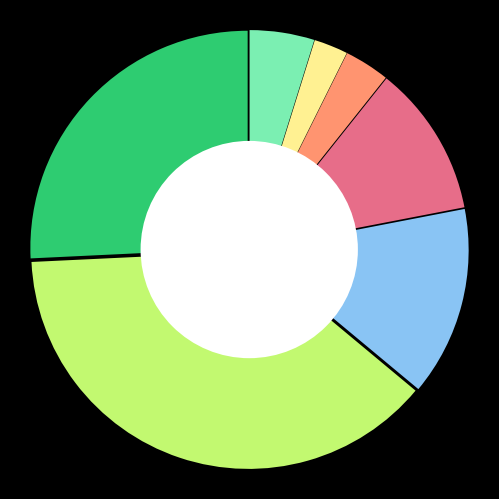

In [14]:
import matplotlib.pyplot as plt
# Pie chart
for s in ['SL003','SL012']:
    sadata = adata[adata.obs.Sample == s]
    sadata = sadata[sadata.X.sum(axis=1) > 25]
    
    #df_table = sadata.obs.pivot_table(values='Area', index='Class', aggfunc=np.sum)
    #df_table = df_table.loc[list(palette_classes.keys()),:]
    #classes = df_table.index.values
    #counts = df_table.Area.values
    
    #classes, counts = np.unique(sadata.obs['Class'], return_counts=True)
    #counts = counts[np.isin(classes,  list(palette_classes.keys()))]
    #classes = classes[np.isin(classes, list(palette_classes.keys()))]
    
    classes, counts = np.unique(sadata.obs['Class'], return_counts=True)
    counts = counts[np.isin(classes,  list(palette_classes.keys()))]
    classes = classes[np.isin(classes, list(palette_classes.keys()))]
    
    p = counts/counts.sum() *100 > 1.5
    counts = counts[p]
    classes = classes[p]

    labels = classes
    sizes = counts
    #colors
    colors = [palette_classes[x] for x in classes]
    #explsion
    explode = [0.01 for c in classes]
    fig1, ax1 = plt.subplots(1,1,figsize=(5,5))
    kwargs={'fontsize':16},
    ax1.pie(
        sizes, 
        colors = colors, 
        #labels=labels, 
        #autopct='%1.1f%%', 
        startangle=90, 
        pctdistance=0.85, 
        explode = explode,
        textprops={'fontsize': 12}
        #kwargs=**kwargs,
    )
    #draw circle
    centre_circle = plt.Circle((0,0),0.50,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax1.axis('equal')  
    plt.tight_layout()
    plt.savefig(f'figures/pie{s}.pdf')
    plt.show()

In [15]:
palette_OL = {'Endothelial':'#8c14fc',  'Mural': '#8c14fc'} | palette_classes

2025-10-29 11:33:07,370 - INFO - First filter, 39655 cells left
2025-10-29 11:33:07,438 - INFO - Zoom filter, 39655 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


2025-10-29 11:33:09,935 - INFO - First filter, 421 cells left
2025-10-29 11:33:09,940 - INFO - Zoom filter, 421 cells left


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


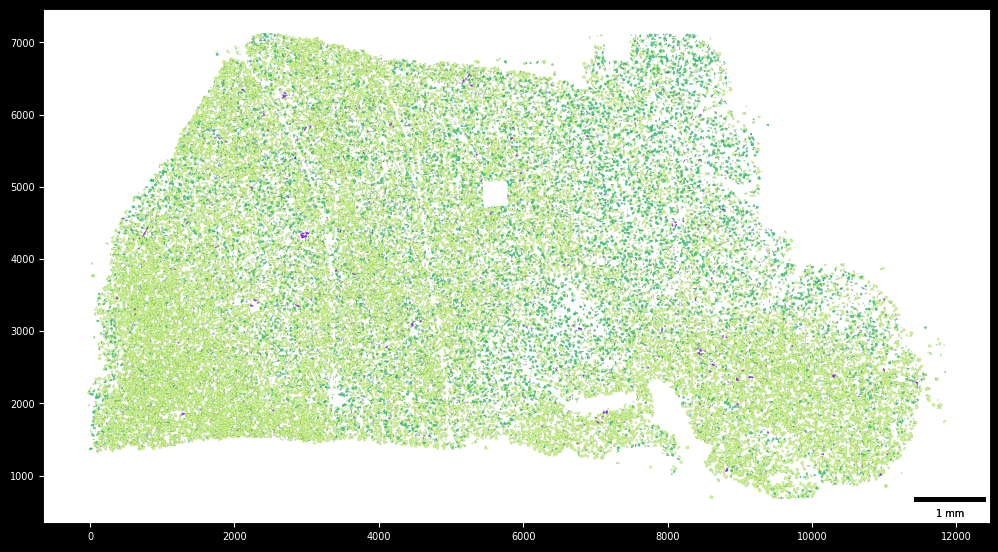

In [16]:
fig,ax = plt.subplots(1,1 ,figsize=(10,10))
sp.pl.plot_polygons(
    adata,
    sample='SL003',
    cluster_key='Class',
    clusters=['GBL-like', 'AC-like', 'OPC-like'], #[45,76],
    alpha=0.9,
    show_axis=True,
    palette= palette_OL,
    ax = ax,

    

)

sp.pl.plot_polygons(
    adata,
    sample='SL003',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    alpha=0.9,
    palette= palette_OL,
    ax=ax,
    show_axis=True
)
#plt.savefig('figures/SL003.svg')


2025-10-29 11:33:10,661 - INFO - First filter, 98962 cells left
2025-10-29 11:33:10,805 - INFO - Zoom filter, 98962 cells left
2025-10-29 11:33:10,809 - INFO - Expression range: 1.0 - 5.1015625
2025-10-29 11:33:11,450 - INFO - First filter, 98962 cells left
2025-10-29 11:33:11,595 - INFO - Zoom filter, 98962 cells left
2025-10-29 11:33:11,599 - INFO - Expression range: 1.0 - 3.0


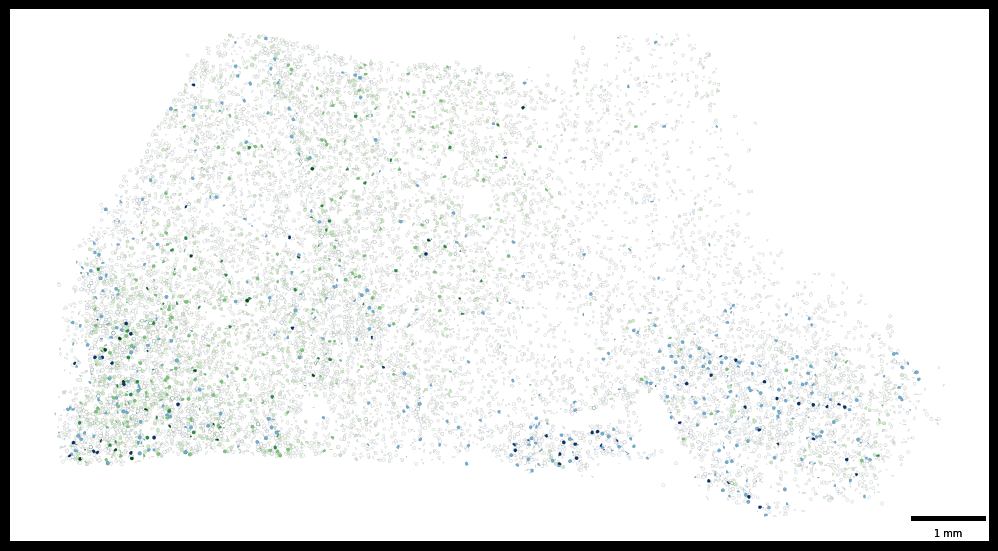

In [17]:
fig,ax = plt.subplots(1,1 ,figsize=(10,10))

sp.pl.plot_polygons_expression(
    adata,
    sample='SL003',
    genes=['EDNRB'],
    cmap='Greens',
    plot_grays=False,
    cluster_key='m-states',
    alpha=1,
    show_axis=False,
    #figsize=(5,5),
    mquant=0.9999,
    ax=ax,

)

sp.pl.plot_polygons_expression(
    adata,
    sample='SL003',
    genes=['OLIG2'],
    cmap='Blues',
    cluster_key='m-states',
    #xlim=xlim,
    #ylim=ylim,
    alpha=1,
    plot_grays=False,
    show_axis=True,
    #figsize=(5,5),
    mquant=0.9999,
    ax=ax,
    #save=True,
    #savepath='figures/SL035B_zoom.svg',
)

plt.savefig('figures/SL003_OLIG1_EDNRB.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

In [ ]:
from FISHscale.utils.dataset import Dataset
from skimage import img_as_bool
from skimage.transform import rescale
import zarr

DS = Dataset('../../data_for_visualization/JJEXP20220210_EEL_SL003_S1_RNA_transformed_assigned.parquet',
             gene_label='decoded_genes',
             pixel_size='0.27 micrometers',
             reparse=True,
            )
'''
img = zarr.load('../../data_for_visualization/JJEXP20220210_EEL_SL003_S1_image_segmented_labels.zarr/segmented_labels_image/')
#img = np.flip(img, axis=0)
img[img >0] = 1
img_d = rescale(img, 0.27, anti_aliasing=False)
img_d[img_d >0] = 1
img_d = img_as_bool(img_d)
#x1, y1, x2, y2 = x1*0.27, y1*0.27, x2*0.27, y2*0.27

'''

 99%|███████████████████████████████████████▍| 878/890 [00:01<00:00, 799.19it/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|████████████████████████████████████████| 890/890 [00:01<00:00, 601.81it/s]


2025-10-29 11:34:22,776 - INFO -     Auto loading color dictionary failed, generating new color dictionary.
2025-10-29 11:34:22,782 - INFO -     Generated new color dictionary and saved as: /Users/amossi/Documents/Karolinska/glioblastoma_wound_response/Example_Notebooks/Extended Data Figure 10/JJEXP20220210_EEL_SL003_S1_RNA_transformed_assigned_FISHscale_Data/JJEXP20220210_EEL_SL003_S1_RNA_transformed_assigned_color_dictionary.pkl
2025-10-29 11:34:22,783 - INFO -     Loaded: JJEXP20220210_EEL_SL003_S1_RNA_transformed_assigned


"\nimg = zarr.load('/datc/sl/fish_rawdata/JJEXP20220210_EEL_SL003_S1/fresh_tissue/segmentation/image_segmented_labels.zarr/segmented_labels_image/')\n#img = np.flip(img, axis=0)\nimg[img >0] = 1\nimg_d = rescale(img, 0.27, anti_aliasing=False)\nimg_d[img_d >0] = 1\nimg_d = img_as_bool(img_d)\n#x1, y1, x2, y2 = x1*0.27, y1*0.27, x2*0.27, y2*0.27\n\n"

In [21]:

DS.color_dict['FN1'] = mcolors.rgb2hex(palette['Mural'])
DS.color_dict['ITM2A'] = mcolors.rgb2hex('#d5b8ff')
DS.color_dict['CLDN5'] = mcolors.rgb2hex('#e33d94')

DS.color_dict['CRYAB'] = mcolors.rgb2hex(palette_classes['AC-like'])
DS.color_dict['AQP4'] = mcolors.rgb2hex('#038aff')

AttributeError: 'Legend' object has no attribute 'legendHandles'

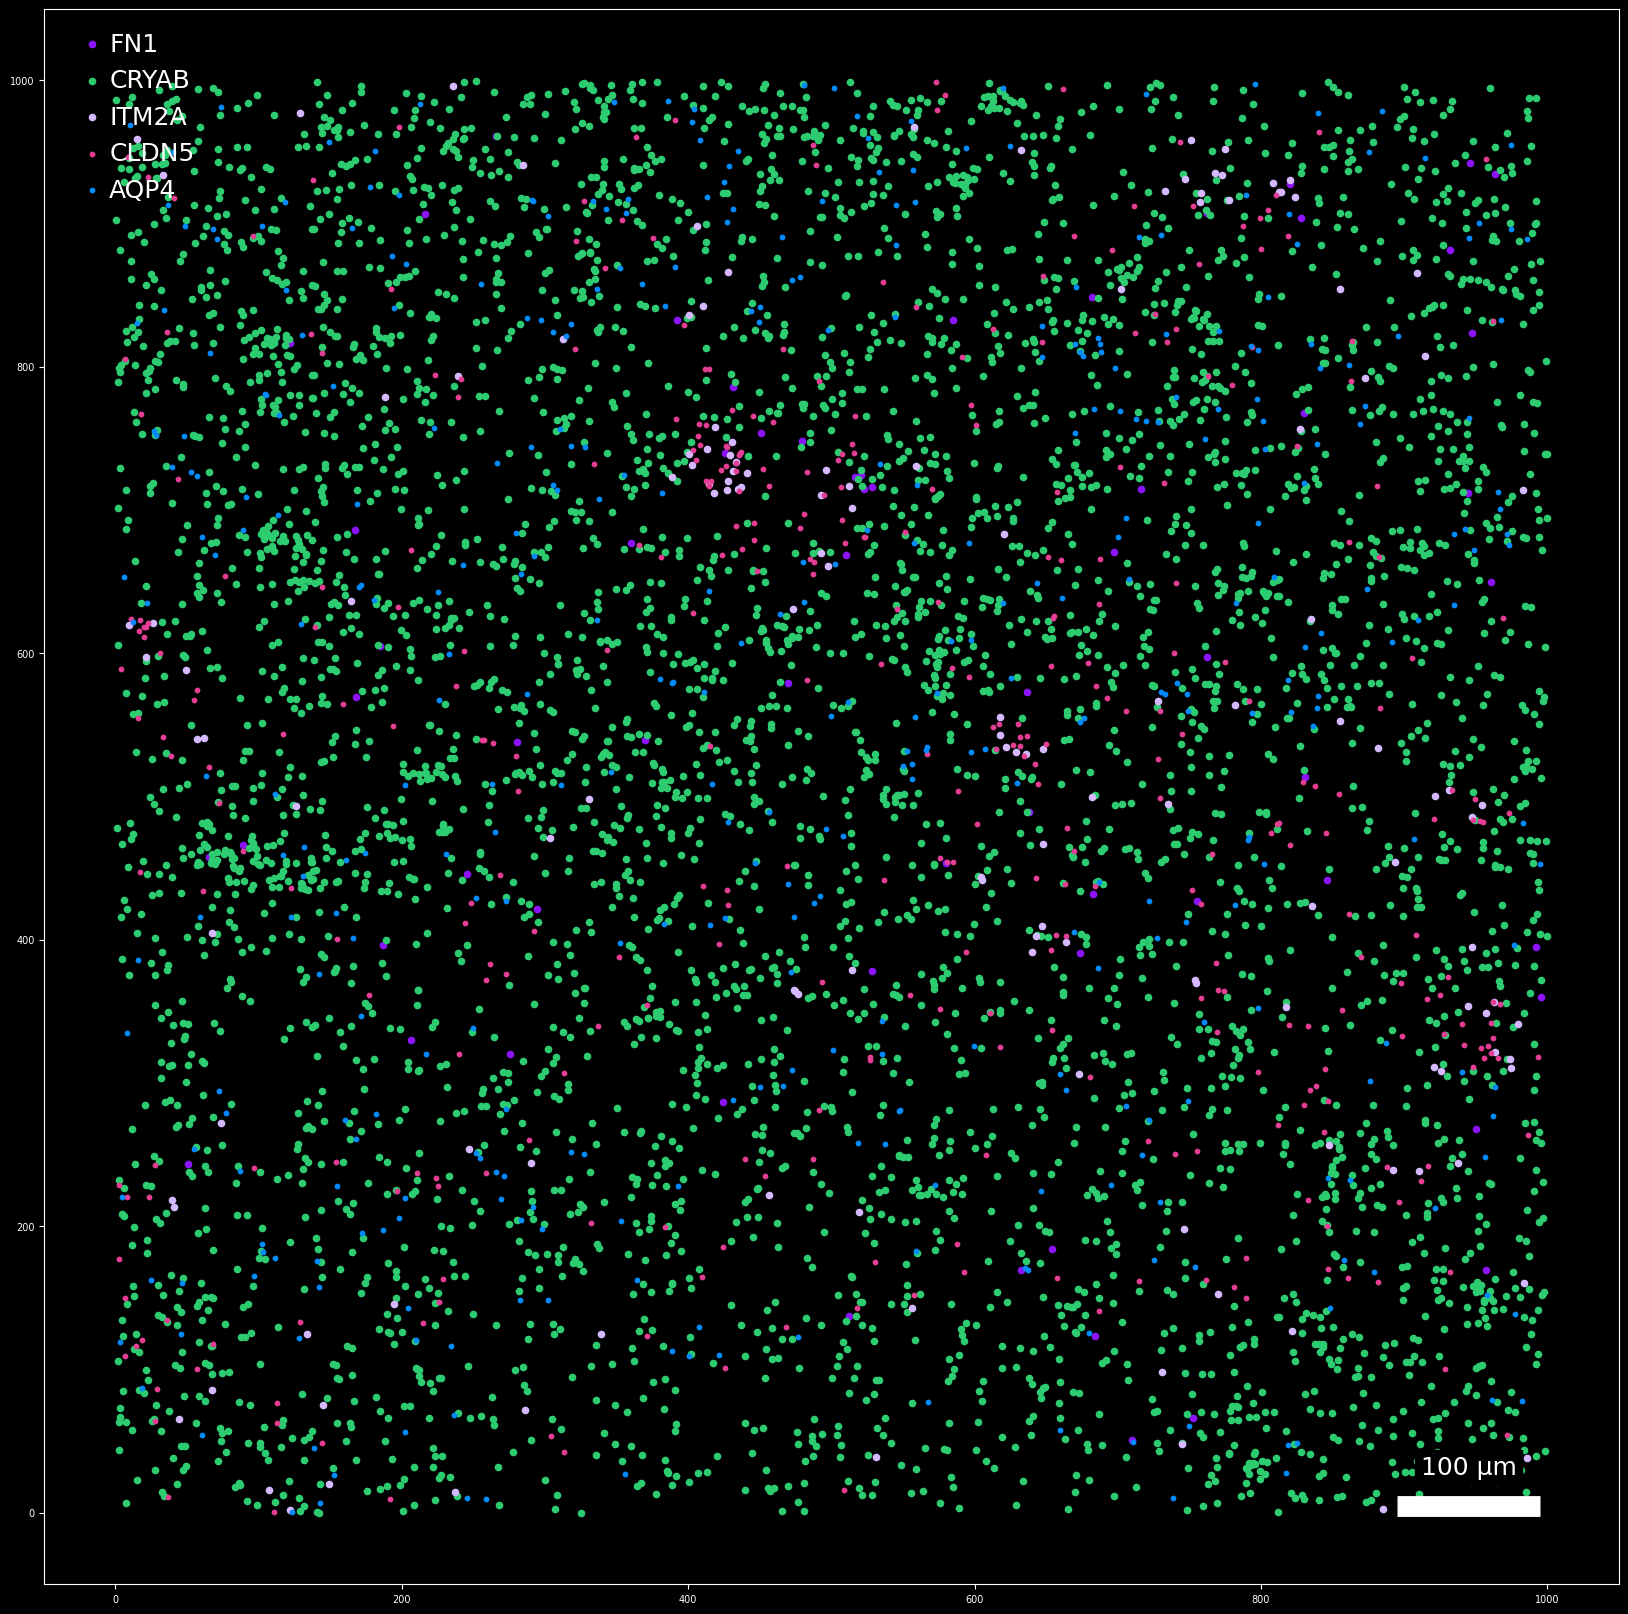

In [22]:

xlim= (8000, 9000)
ylim = (2000, 3000)

xlim_rev = ()
ylim_rev = ()

v =  [[xlim[0], ylim[0]],[xlim[1],ylim[1]]]

scale_factor = 1#0.27*4.5
#img_zoom = img_d[int(v[0][1]*scale_factor):int(v[1][1]*scale_factor),int(v[0][0]*scale_factor):int(v[1][0]*scale_factor)]

sizes = [20, 20, 20, 10, 10] 
genes = ['FN1','CRYAB','ITM2A','CLDN5','AQP4']

fig,ax = plt.subplots(1,1 ,figsize=(5,5))

DS.scatter_plot(
    genes,
    s=sizes,
    ax_scale_factor=400,
    show_axes=True,
    show_legend=True,
    view = v,
    #image=img_zoom,
    reset_xy=True,
    ax=ax,
    save=True,
    save_name='figures/SL003_dots.svg'
)
